# Libraries

In [ ]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

import warnings
warnings.filterwarnings('ignore')

# Task 1: Data Cleaning and Preprocessing

In [2]:
# Loading the dataset 
column_names = [ 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
    
]

b_housing = pd.read_csv(
    r"c:\Users\DELL\Downloads\4) house Prediction Data Set.csv",
    sep=r'\s+',
    engine= 'python',
    header= None,
    names = column_names,
    na_values= ['NA', 'missing', '', '?']
)

b_housing_copied = b_housing
print(b_housing_copied.shape )

b_housing_copied.head(3)


(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7


In [3]:
# Checking data Quality 

print ("Missing values per column:\n",b_housing_copied.isna().sum())

Missing values per column:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
print ("\nDuplicate rows:", b_housing_copied.duplicated().sum())

print ("\nData types:\n", b_housing_copied.dtypes)

print ("\nData info:\n", b_housing_copied.info())


Duplicate rows: 0

Data types:
 CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV   

In [5]:
# Outlier detection & handling

def cap_outliers_iqr(series, multiplier = 1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    return series.clip(lower = lower, upper = upper)

outlier_cols = ['CRIM', 'ZN', 'RM', 'DIS', 'B', 'LSTAT', 'MEDV' ]

for col in outlier_cols: 
    b_housing_copied[col] = cap_outliers_iqr(b_housing_copied[col])
    
    print( b_housing_copied[outlier_cols].describe().round(2))

         CRIM      ZN      RM     DIS       B   LSTAT    MEDV
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00
mean     2.23   11.36    6.28    3.80  356.67   12.65   22.53
std      3.31   23.32    0.70    2.11   91.29    7.14    9.20
min      0.01    0.00    3.56    1.13    0.32    1.73    5.00
25%      0.08    0.00    5.89    2.10  375.38    6.95   17.02
50%      0.26    0.00    6.21    3.21  391.44   11.36   21.20
75%      3.68   12.50    6.62    5.19  396.22   16.96   25.00
max      9.07  100.00    8.78   12.13  396.90   37.97   50.00
         CRIM      ZN      RM     DIS       B   LSTAT    MEDV
count  506.00  506.00  506.00  506.00  506.00  506.00  506.00
mean     2.23    6.96    6.28    3.80  356.67   12.65   22.53
std      3.31   12.03    0.70    2.11   91.29    7.14    9.20
min      0.01    0.00    3.56    1.13    0.32    1.73    5.00
25%      0.08    0.00    5.89    2.10  375.38    6.95   17.02
50%      0.26    0.00    6.21    3.21  391.44   11.36   21.20
75%     

In [6]:
#   Standardizing formats & fixing data types

b_housing_copied['CHAS'] =b_housing_copied['CHAS'].astype('category')

b_housing_copied['RAD'] =b_housing_copied['RAD'].astype('category')

# Ensuring numeric columns are float

numeric_cols = ['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','TAX','PTRATIO','B','LSTAT','MEDV']

b_housing_copied[numeric_cols] = b_housing_copied[numeric_cols].astype(float)

b_housing_copied.dtypes

CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
MEDV        float64
dtype: object

In [7]:
b_housing_copied['RM2']          = b_housing_copied['RM'] ** 2                    
b_housing_copied['LSTAT_bin']    = pd.qcut(b_housing_copied['LSTAT'], q=5, labels=False)  
b_housing_copied['CRIM_log']     = np.log1p(b_housing_copied['CRIM'])              
b_housing_copied['PRICE_per_ROOM'] = b_housing_copied['MEDV'] / b_housing_copied['RM']

In [8]:

print("FINAL CLEANED DATASET SUMMARY")
print("="*40)
print("Shape:", b_housing_copied.shape)
print("\nMissing values total:", b_housing_copied.isna().sum().sum())
print("\nSample of cleaned data:")
print(b_housing_copied.head(5).round(2))


FINAL CLEANED DATASET SUMMARY
Shape: (506, 18)

Missing values total: 0

Sample of cleaned data:
   CRIM    ZN  INDUS CHAS   NOX    RM   AGE   DIS RAD    TAX  PTRATIO       B  \
0  0.01  18.0   2.31    0  0.54  6.58  65.2  4.09   1  296.0     15.3  396.90   
1  0.03   0.0   7.07    0  0.47  6.42  78.9  4.97   2  242.0     17.8  396.90   
2  0.03   0.0   7.07    0  0.47  7.18  61.1  4.97   2  242.0     17.8  392.83   
3  0.03   0.0   2.18    0  0.46  7.00  45.8  6.06   3  222.0     18.7  394.63   
4  0.07   0.0   2.18    0  0.46  7.15  54.2  6.06   3  222.0     18.7  396.90   

   LSTAT  MEDV    RM2  LSTAT_bin  CRIM_log  PRICE_per_ROOM  
0   4.98  24.0  43.23          0      0.01            3.65  
1   9.14  21.6  41.23          1      0.03            3.36  
2   4.03  34.7  51.62          0      0.03            4.83  
3   2.94  33.4  48.97          0      0.03            4.77  
4   5.33  36.2  51.08          0      0.07            5.07  


In [9]:
# Exporting the cleaned dataset

# b_housing_copied.to_csv('housing_prediction_cleaned.csv', index=False)

# Task 2: Exploratory Data Analysis (EDA)

In [10]:
#  Summary Statistics

print("\nDescriptive statistics of main variables:")
print(b_housing_copied[['CRIM','RM','LSTAT','MEDV','PRICE_per_ROOM']].describe().round(2))


Descriptive statistics of main variables:
         CRIM      RM   LSTAT    MEDV  PRICE_per_ROOM
count  506.00  506.00  506.00  506.00          506.00
mean     2.23    6.28   12.61   21.88            3.44
std      3.31    0.63    7.02    7.60            0.98
min      0.01    4.78    1.73    5.06            0.89
25%      0.08    5.89    6.95   17.02            2.86
50%      0.26    6.21   11.36   21.20            3.47
75%      3.68    6.62   16.96   25.00            4.04
max      9.07    7.73   31.96   36.96            7.44


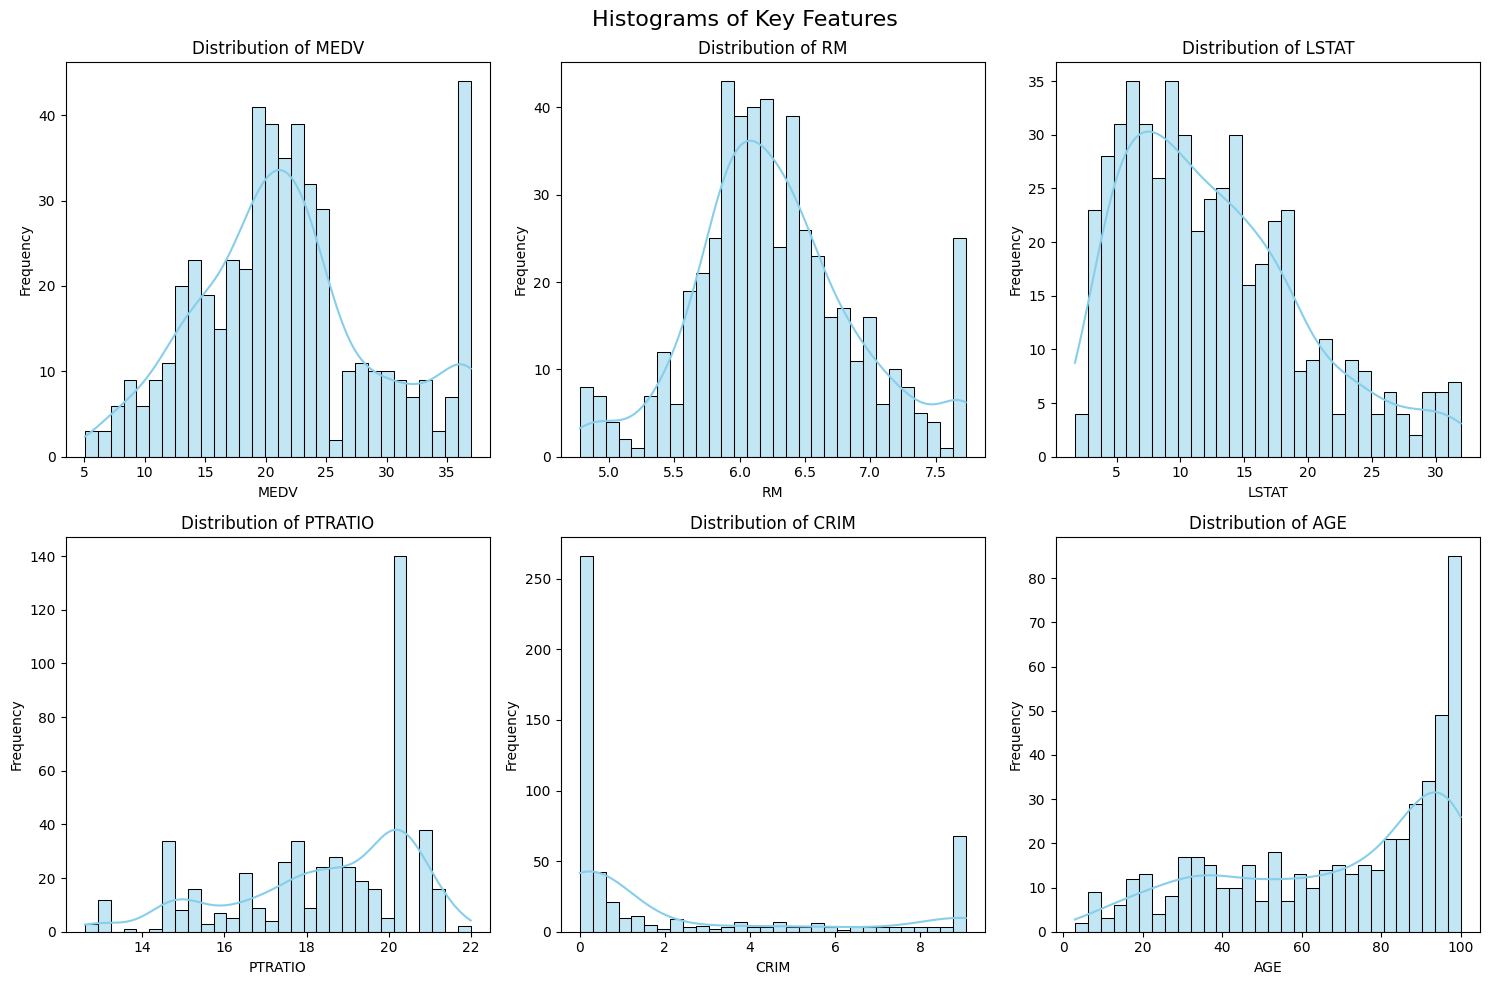

In [11]:
#  Histograms - Distribution of Features 
plt.figure(figsize=(15, 10))

features = ['MEDV', 'RM', 'LSTAT', 'PTRATIO', 'CRIM', 'AGE']
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(b_housing_copied[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.suptitle('Histograms of Key Features', fontsize=16)
plt.tight_layout()
plt.savefig('boston_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

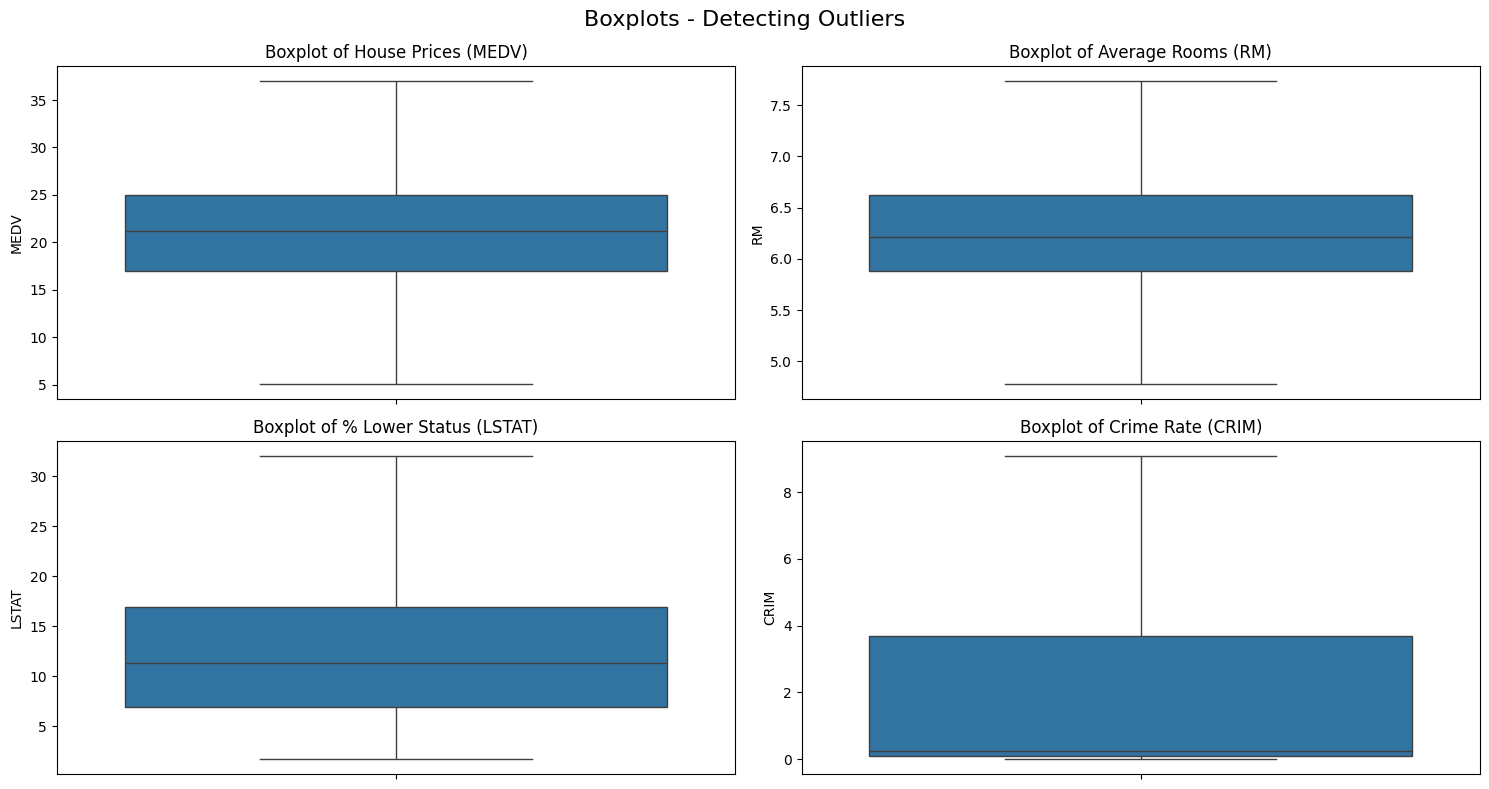

In [12]:
#   Boxplots - Outlier Detection 
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=b_housing_copied['MEDV'])
plt.title('Boxplot of House Prices (MEDV)')

plt.subplot(2, 2, 2)
sns.boxplot(y=b_housing_copied['RM'])
plt.title('Boxplot of Average Rooms (RM)')

plt.subplot(2, 2, 3)
sns.boxplot(y=b_housing_copied['LSTAT'])
plt.title('Boxplot of % Lower Status (LSTAT)')

plt.subplot(2, 2, 4)
sns.boxplot(y=b_housing_copied['CRIM'])
plt.title('Boxplot of Crime Rate (CRIM)')

plt.suptitle('Boxplots - Detecting Outliers', fontsize=16)
plt.tight_layout()
plt.savefig('boston_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

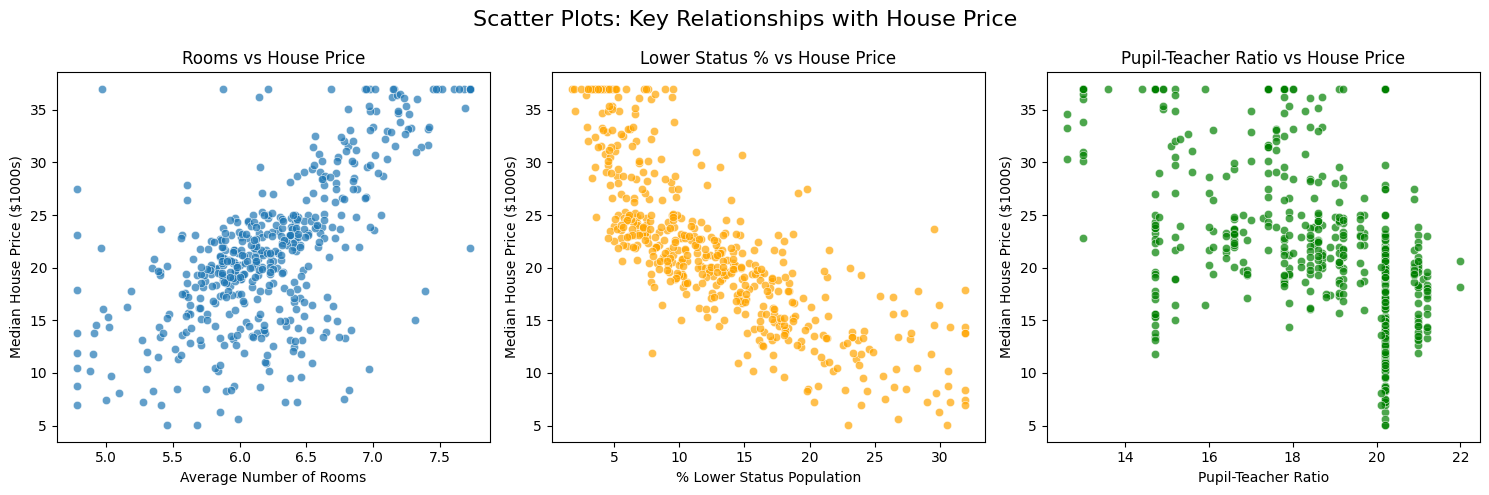

In [13]:
#  Scatter Plots - Relationships 
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='RM', y='MEDV', data=b_housing_copied, alpha=0.7)
plt.title('Rooms vs House Price')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Price ($1000s)')

plt.subplot(1, 3, 2)
sns.scatterplot(x='LSTAT', y='MEDV', data=b_housing_copied, alpha=0.7, color='orange')
plt.title('Lower Status % vs House Price')
plt.xlabel('% Lower Status Population')
plt.ylabel('Median House Price ($1000s)')

plt.subplot(1, 3, 3)
sns.scatterplot(x='PTRATIO', y='MEDV', data=b_housing_copied, alpha=0.7, color='green')
plt.title('Pupil-Teacher Ratio vs House Price')
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Median House Price ($1000s)')

plt.suptitle('Scatter Plots: Key Relationships with House Price', fontsize=16)
plt.tight_layout()
plt.savefig('boston_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

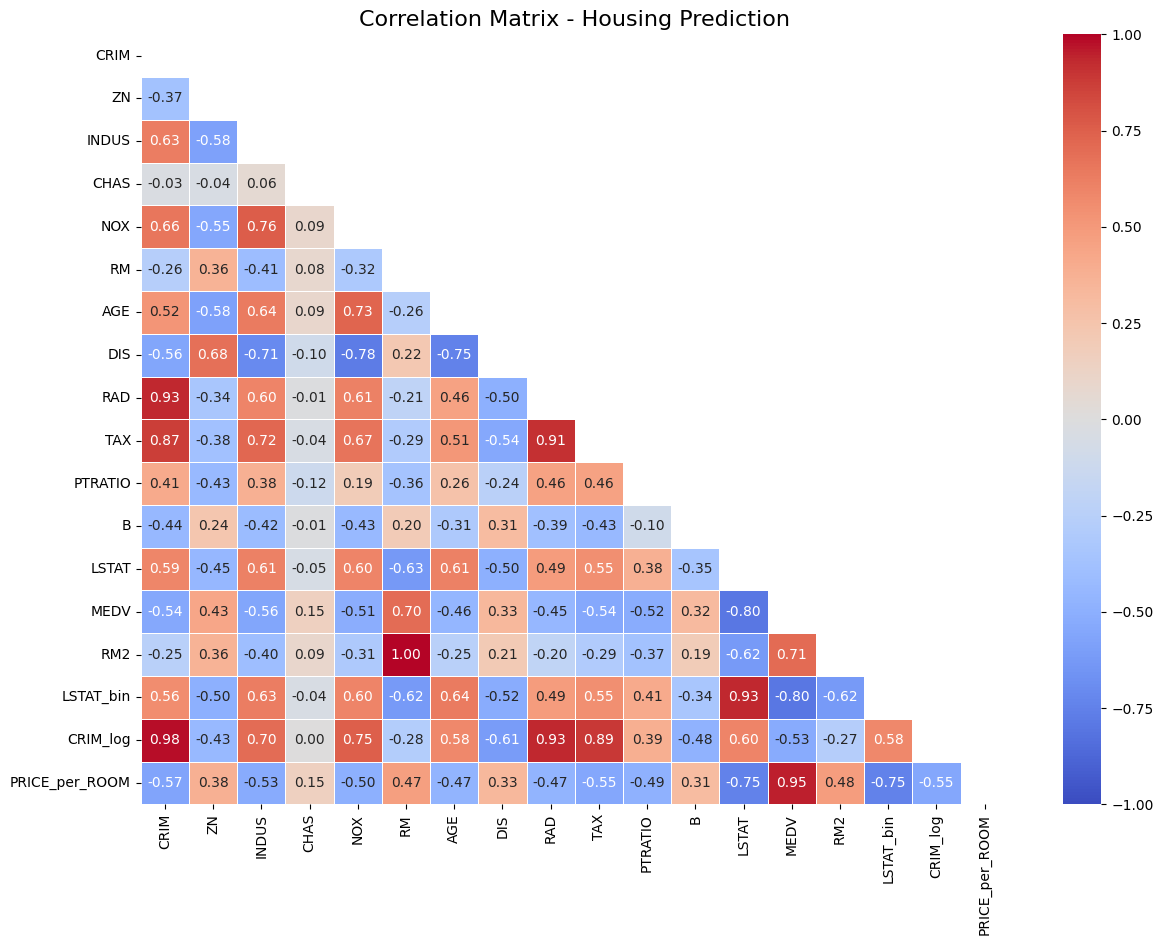

In [14]:
#  Correlation Heatmap

plt.figure(figsize=(14, 10))
corr = b_housing_copied.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Matrix - Housing Prediction', fontsize=16)
plt.savefig('boston_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
#  Strongest relationships with target (MEDV)

print("\nTop correlations with MEDV:")
print(
    corr['MEDV']
    .drop('MEDV')
    .sort_values(ascending=False)
    .round(3)
)


Top correlations with MEDV:
PRICE_per_ROOM    0.95
RM2               0.71
RM                0.70
ZN                0.43
DIS               0.33
B                 0.32
CHAS              0.15
RAD              -0.45
AGE              -0.46
NOX              -0.51
PTRATIO          -0.52
CRIM_log         -0.53
CRIM             -0.54
TAX              -0.54
INDUS            -0.56
LSTAT            -0.80
LSTAT_bin        -0.80
Name: MEDV, dtype: float64


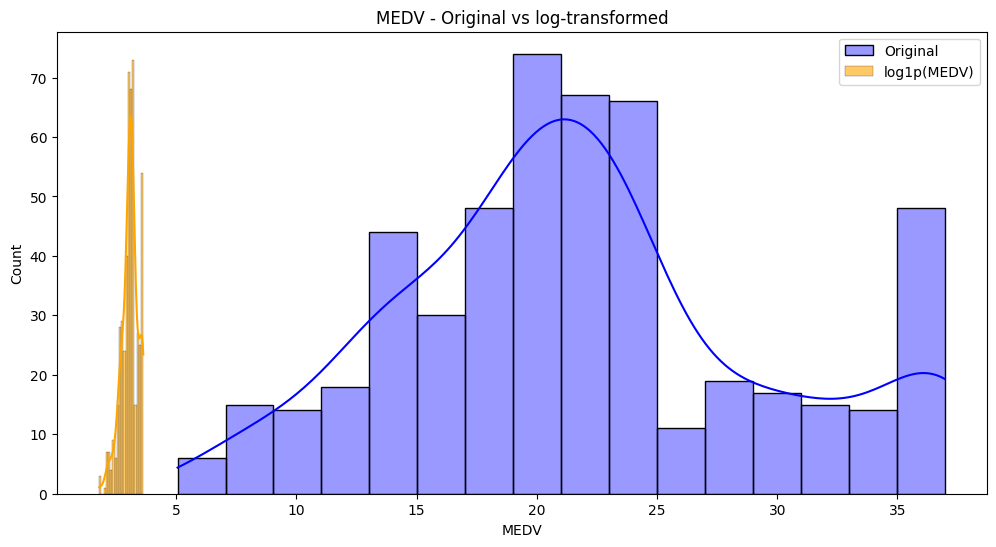

In [16]:
#  Log transform skewed features 

b_housing_copied_log = b_housing_copied.copy()
for col in ['CRIM', 'ZN', 'DIS', 'B', 'MEDV']:
    if (b_housing_copied[col] > 0).all():
        b_housing_copied_log[col] = np.log1p(b_housing_copied[col])

# Comparing distributions before/after
plt.figure(figsize=(12, 6))
sns.histplot(b_housing_copied['MEDV'], kde=True, color='blue', alpha=0.4, label='Original')
sns.histplot(b_housing_copied_log['MEDV'], kde=True, color='orange', alpha=0.6, label='log1p(MEDV)')
plt.title('MEDV - Original vs log-transformed')
plt.legend()
plt.show()

# Task 3: Basic Data Visualization

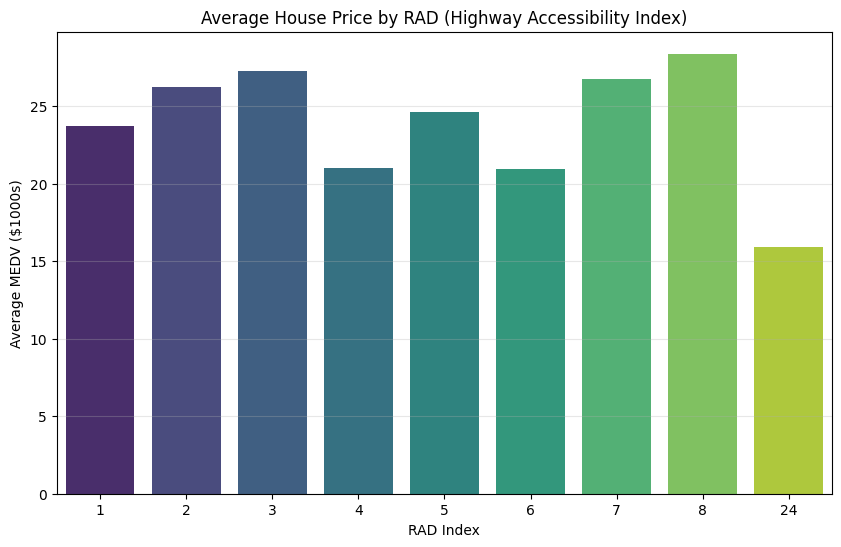

In [17]:
#  Bar Plot - Average Price by RAD 

plt.figure(figsize=(10, 6))
rad_avg_price = b_housing_copied.groupby('RAD', observed=False)['MEDV'].mean().sort_values(ascending=False)
sns.barplot(x=rad_avg_price.index, 
            y=rad_avg_price.values, 
            hue=rad_avg_price.index, 
            palette='viridis', 
            legend=False
)
plt.title('Average House Price by RAD (Highway Accessibility Index)')
plt.xlabel('RAD Index')
plt.ylabel('Average MEDV ($1000s)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('boston_barplot_rad.png', dpi=300, bbox_inches='tight')
plt.show()

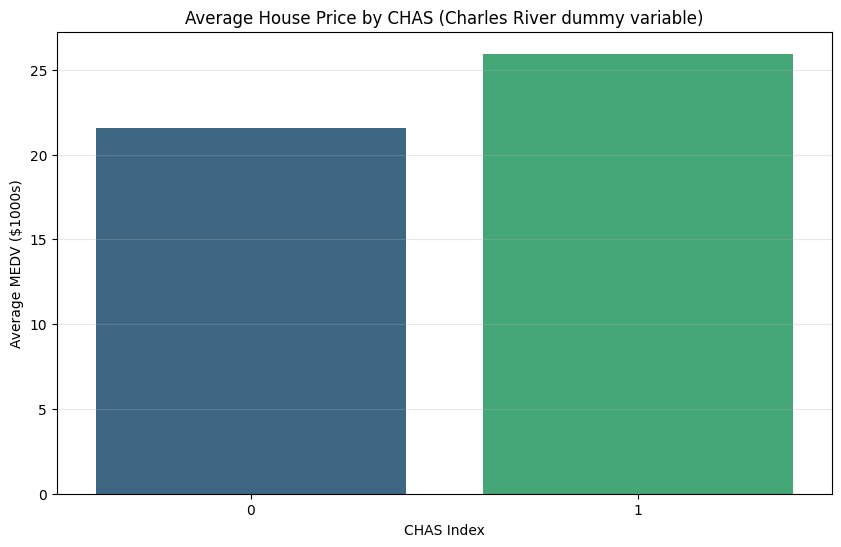

In [18]:
#  Bar Plot - Average Price by CHAS 

plt.figure(figsize=(10, 6))
chas_avg_price = b_housing_copied.groupby('CHAS', observed=False)['MEDV'].mean().sort_values(ascending=False)
sns.barplot(x=chas_avg_price.index, 
            y=chas_avg_price.values, 
            hue=chas_avg_price.index, 
            palette='viridis', 
            legend=False
)
plt.title('Average House Price by CHAS (Charles River dummy variable)')
plt.xlabel('CHAS Index')
plt.ylabel('Average MEDV ($1000s)')
plt.grid(axis='y', alpha=0.3)
plt.savefig('boston_barplot_chas.png', dpi=300, bbox_inches='tight')
plt.show()